In [ ]:
import pandas as pd

df = pd.read_csv('train.csv')

In [ ]:
df.head()


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878049 entries, 0 to 878048
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Dates       878049 non-null  object 
 1   Category    878049 non-null  object 
 2   Descript    878049 non-null  object 
 3   DayOfWeek   878049 non-null  object 
 4   PdDistrict  878049 non-null  object 
 5   Resolution  878049 non-null  object 
 6   Address     878049 non-null  object 
 7   X           878049 non-null  float64
 8   Y           878049 non-null  float64
dtypes: float64(2), object(7)
memory usage: 60.3+ MB


In [ ]:
df.describe()

,X,Y
count,878049.000000,878049.000000
mean,-122.422616,37.771020
std,0.030354,0.456893
min,-122.513642,37.707879
25%,-122.432952,37.752427
50%,-122.416420,37.775421
75%,-122.406959,37.784369
max,-120.500000,90.000000


In [ ]:
df.columns

Index(['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict',
       'Resolution', 'Address', 'X', 'Y'],
      dtype='object')

Checking for null values

In [ ]:
df.isnull().sum()

,0
Dates,0
Category,0
Descript,0
DayOfWeek,0
PdDistrict,0
Resolution,0
Address,0
X,0
Y,0


Date Formating

In [ ]:
df['Dates'] = pd.to_datetime(df['Dates'])

df['Hour'] = df['Dates'].dt.hour
df['Month'] = df['Dates'].dt.month
df['Day'] = df['Dates'].dt.day

Standardizing text columns

In [ ]:
cols = ['Category', 'PdDistrict', 'DayOfWeek', 'Address']

for col in cols:
    df[col] = df[col].astype(str).str.strip().str.upper()

Checking for duplicates

In [ ]:
df.duplicated().sum()


np.int64(2323)

In [ ]:
duplicates = df[df.duplicated(keep=False)]

first_group_key = list(duplicates.groupby(list(df.columns)).groups.keys())[0]

duplicates.groupby(list(df.columns)).get_group(first_group_key)

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y,Hour,Month,Day
877346,2003-01-07 18:25:00,PROSTITUTION,SOLICITS FOR ACT OF PROSTITUTION,TUESDAY,NORTHERN,"ARREST, CITED",HEMLOCK ST / LARKIN ST,-122.418369,37.787486,18,1,7
877348,2003-01-07 18:25:00,PROSTITUTION,SOLICITS FOR ACT OF PROSTITUTION,TUESDAY,NORTHERN,"ARREST, CITED",HEMLOCK ST / LARKIN ST,-122.418369,37.787486,18,1,7


Removing duplicates

In [ ]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 2323
Duplicates after: 0


Handling outliers

In [ ]:
df = df[(df['X'] > -122.55) & (df['X'] < -122.33)]
df = df[(df['Y'] > 37.65) & (df['Y'] < 37.85)]

In [ ]:
df.to_csv('sf_crime_cleaned.csv', index=False)

In [ ]:
cleaned = pd.read_csv('sf_crime_cleaned.csv')
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875659 entries, 0 to 875658
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Dates       875659 non-null  object 
 1   Category    875659 non-null  object 
 2   Descript    875659 non-null  object 
 3   DayOfWeek   875659 non-null  object 
 4   PdDistrict  875659 non-null  object 
 5   Resolution  875659 non-null  object 
 6   Address     875659 non-null  object 
 7   X           875659 non-null  float64
 8   Y           875659 non-null  float64
 9   Hour        875659 non-null  int64  
 10  Month       875659 non-null  int64  
 11  Day         875659 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 80.2+ MB


Crime Analysis

Spatial

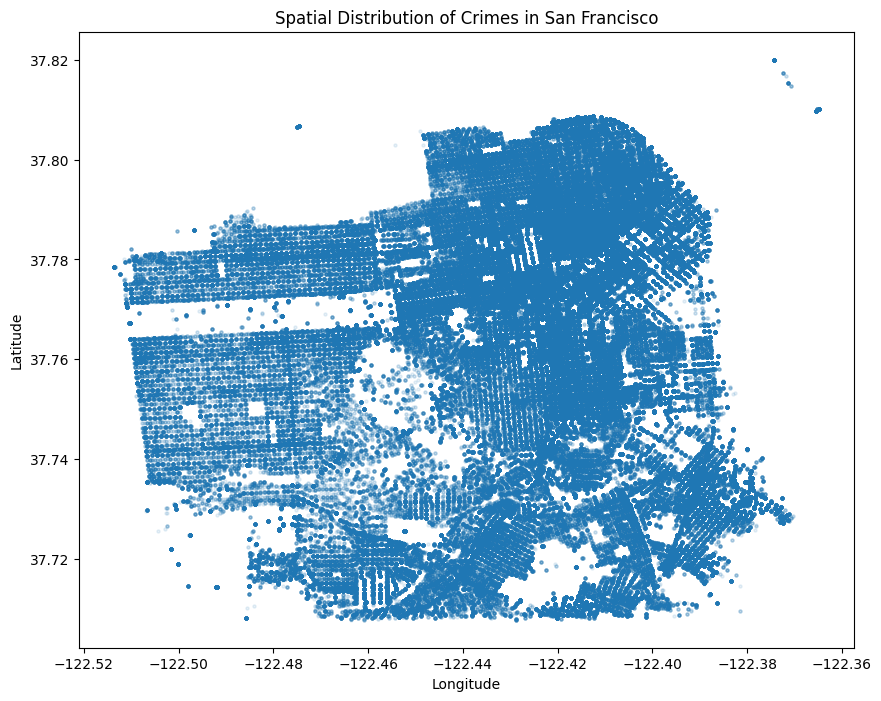

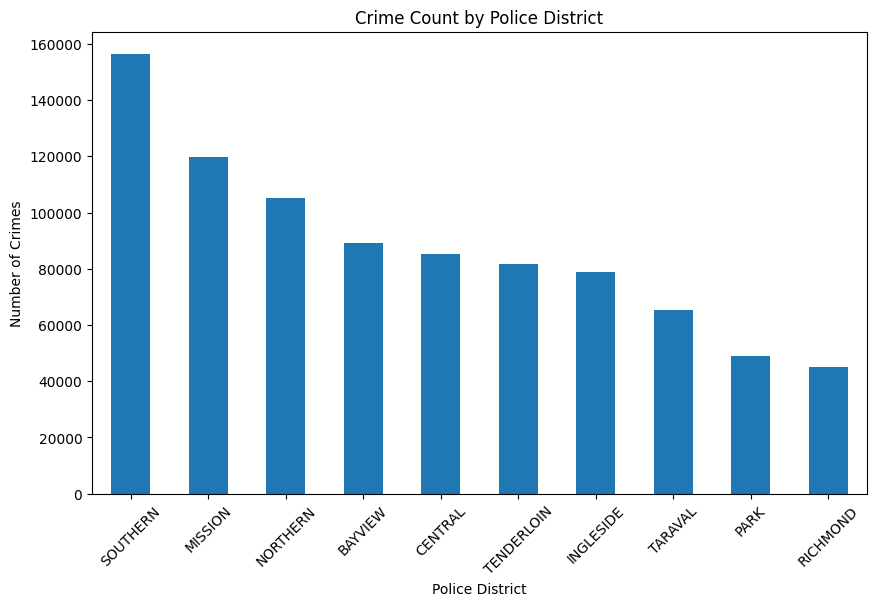

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(df['X'], df['Y'], alpha=0.1, s=5)
plt.title('Spatial Distribution of Crimes in San Francisco')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# District crime counts
plt.figure(figsize=(10, 6))
df['PdDistrict'].value_counts().plot(kind='bar')
plt.title('Crime Count by Police District')
plt.xlabel('Police District')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

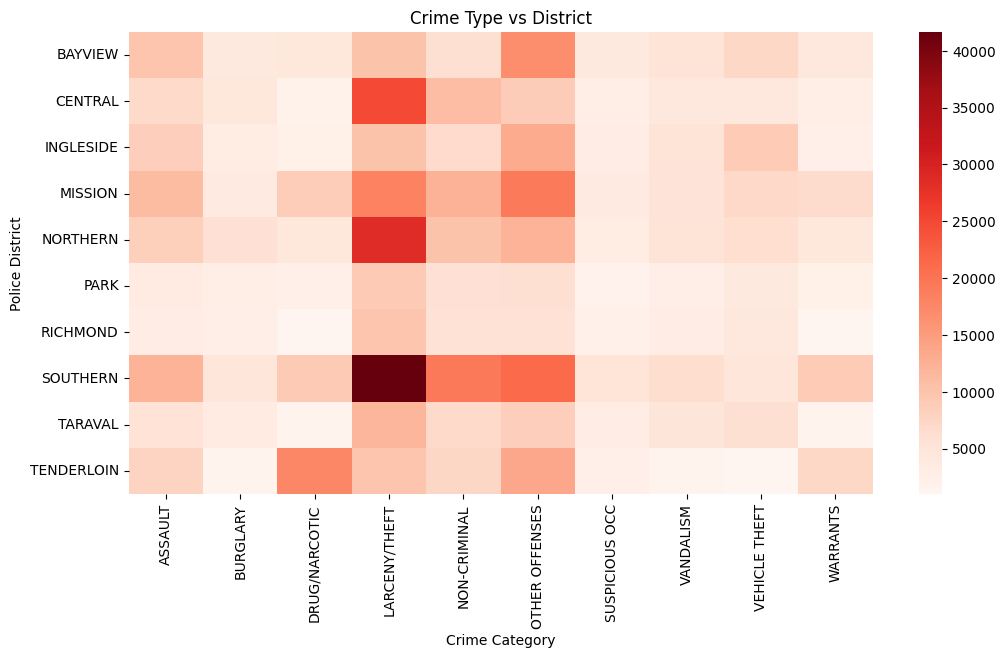

In [ ]:
top_crimes = df['Category'].value_counts().head(10).index
filtered_df = df[df['Category'].isin(top_crimes)]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pd.crosstab(filtered_df['PdDistrict'], filtered_df['Category']), cmap='Reds')
plt.title("Crime Type vs District")
plt.xlabel("Crime Category")
plt.ylabel("Police District")
plt.show()

Temporal


<Axes: xlabel='Hour'>

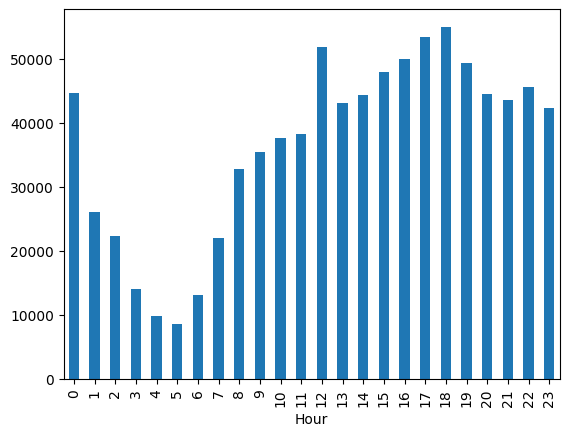

In [ ]:
df['Hour'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='DayOfWeek'>

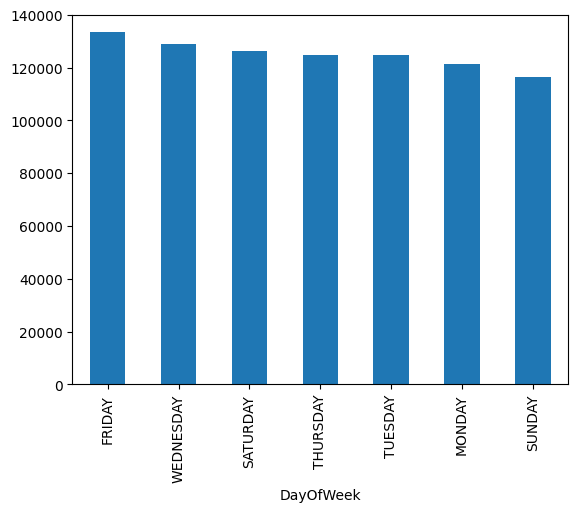

In [ ]:
df['DayOfWeek'].value_counts().plot(kind='bar')

M2

Spatial


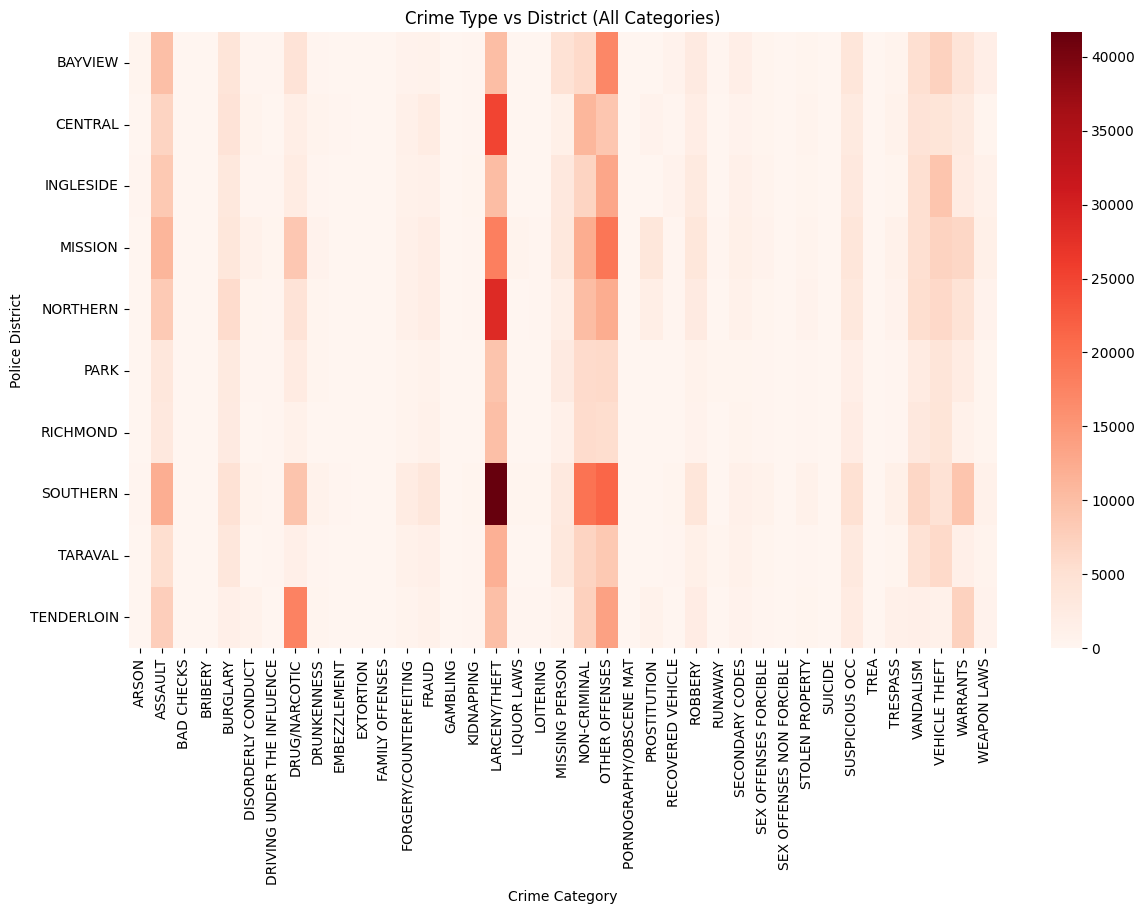

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
sns.heatmap(pd.crosstab(df['PdDistrict'], df['Category']), cmap='Reds')
plt.title("Crime Type vs District (All Categories)")
plt.xlabel("Crime Category")
plt.ylabel("Police District")
plt.show()

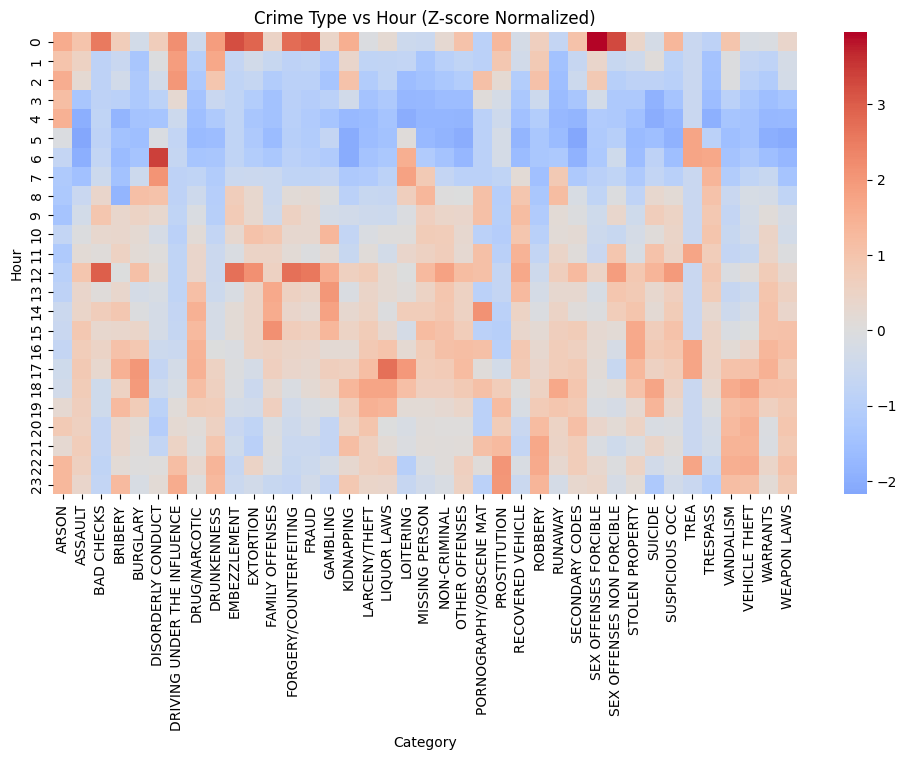

In [ ]:
from scipy.stats import zscore

ct = pd.crosstab(df['Hour'], df['Category'])

ct_z = ct.apply(zscore)

plt.figure(figsize=(12,6))
sns.heatmap(ct_z, cmap='coolwarm', center=0)
plt.title("Crime Type vs Hour (Z-score Normalized)")
plt.show()

In [ ]:
pd.crosstab(df['Hour'], df['Category'])

Category,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,...,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TREA,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
Hour,,,,,,,,,,,,,,,,,,,,,
0,101,4285,65,16,1357,234,299,1702,372,238,...,23,219,19,2030,0,215,2672,2031,1679,411
1,87,3785,1,9,832,176,272,1043,349,7,...,3,158,22,844,0,153,1830,1388,1203,322
2,100,3452,1,10,876,151,285,808,272,2,...,1,128,14,793,0,146,1810,1115,977,313
3,91,1737,1,7,865,110,118,546,120,2,...,0,101,5,553,0,132,1104,669,687,160
4,98,1052,2,2,768,70,51,379,59,2,...,0,81,4,366,0,97,711,503,566,113
5,61,825,1,4,704,172,26,205,13,2,...,1,68,8,287,1,207,572,497,398,60
6,47,1034,3,3,792,454,34,600,40,2,...,4,73,14,468,1,486,657,739,712,103
7,35,1579,8,4,1269,346,16,1309,66,17,...,2,101,15,793,0,453,929,1265,1336,156
8,33,2568,24,2,2116,263,15,1731,72,89,...,6,130,24,1408,0,418,1391,1998,1589,246


<Axes: xlabel='Category', ylabel='Hour'>

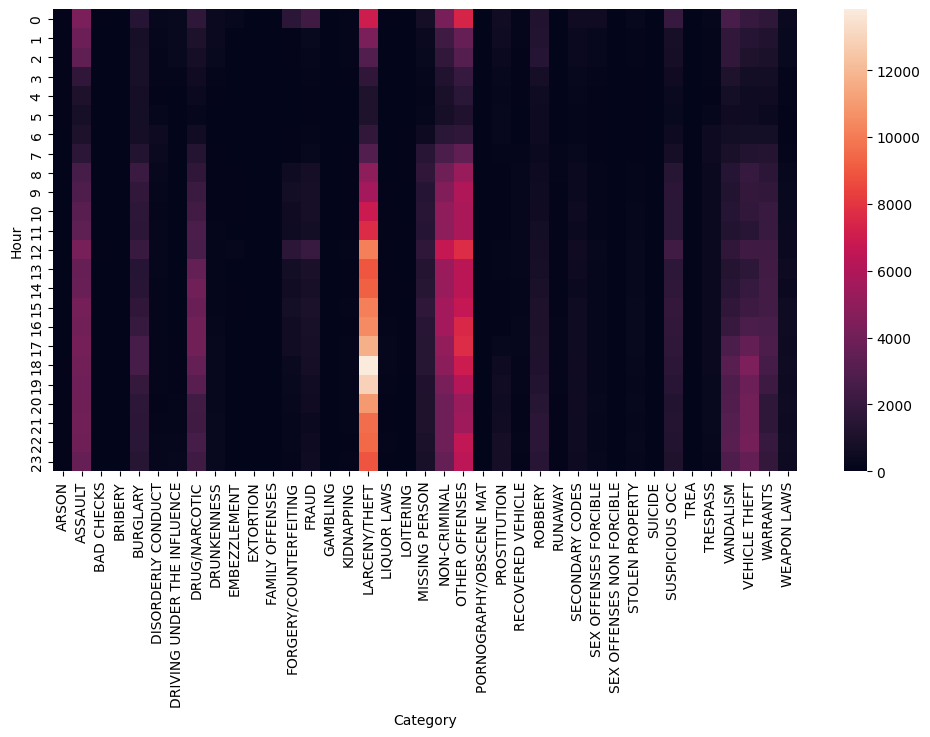

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pd.crosstab(df['Hour'], df['Category']))